In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df = pd.read_csv("aptitudes_ninja.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   fuerza_fisica   150 non-null    float64
 1   control_chakra  150 non-null    float64
 2   misiones_exito  150 non-null    int64  
 3   nombre_sujeto   150 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 4.8+ KB


---
# 1. Exploración y Limpieza del CSV.

### Carga el CSV y verifica que no existan valores nulos o incoherentes (por ejemplo, chakra negativo). Solo utilizaremos las columnas numéricas de fuerza_fisica y control_chakra para el modelo.

### Vemos todos los nulos

In [30]:
df.isna().sum()

,0
fuerza_fisica,0
control_chakra,0
misiones_exito,0
nombre_sujeto,0


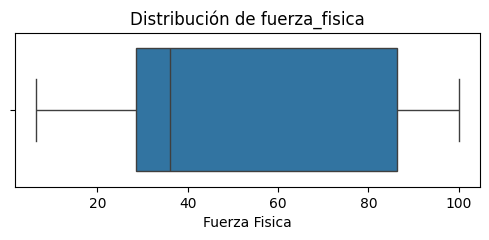

In [31]:
plt.figure(figsize=(6,2))
sns.boxplot(x=df["fuerza_fisica"])
plt.title("Distribución de fuerza_fisica")
plt.xlabel("Fuerza Fisica")
plt.show()

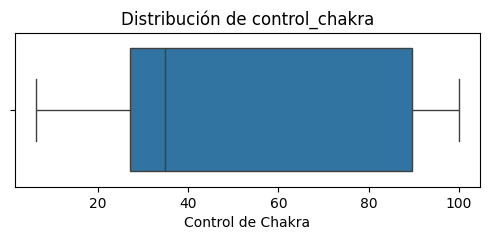

In [32]:
plt.figure(figsize=(6,2))
sns.boxplot(x=df["control_chakra"])
plt.title("Distribución de control_chakra")
plt.xlabel("Control de Chakra")
plt.show()



---


# 2. Encontrar el “K” Óptimo.

###No sabemos cuántas unidades especializadas debemos crear. Aplica el Método del Codo evaluando inercias desde K=1 hasta K=10. Justifica tu elección del número de clústeres.

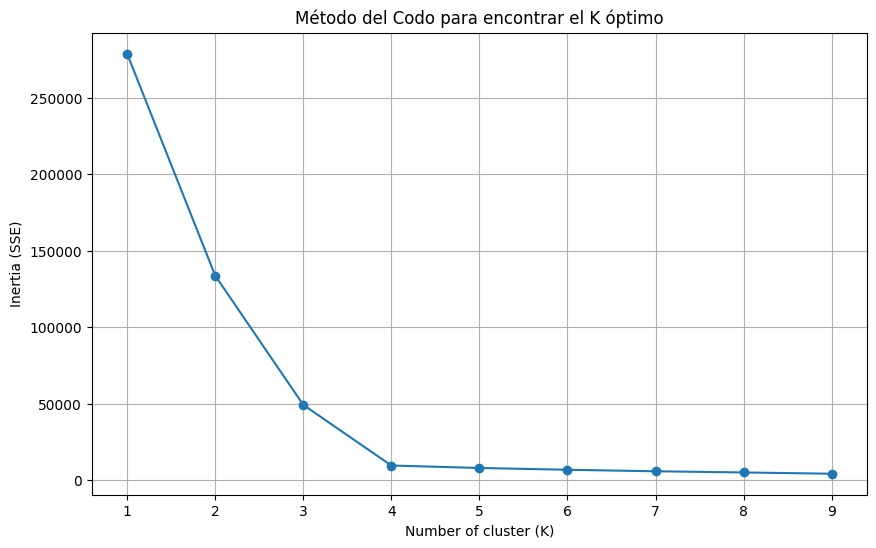

In [33]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Selecting the correct features from the existing 'df' DataFrame
X = df[['fuerza_fisica', 'control_chakra']]

data = X

sse = {}
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000, random_state=42, n_init=10).fit(data)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
plt.figure(figsize=(10, 6))
plt.plot(list(sse.keys()), list(sse.values()), marker='o')
plt.xlabel("Number of cluster (K)")
plt.ylabel("Inertia (SSE)")
plt.title("Método del Codo para encontrar el K óptimo")
plt.xticks(range(1, 10))
plt.grid(True)
plt.show()

---
# 3. Entrenamiento y Clasificación.

### Entrena el modelo K-Means con el K elegido y asigna a cada ninja su clúster correspondiente. Añade esta etiqueta como una nueva columna en tu DataFrame original.

In [34]:
# 2. Invocamos el jutsu de clustering (K=3)
# n_init asegura que probamos diferentes posiciones iniciales para evitar óptimos locales
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['clan_comportamiento'] = kmeans.fit_predict(X)

# 3. Identificación del centro de mando
centroides = kmeans.cluster_centers_

In [35]:
df

,fuerza_fisica,control_chakra,misiones_exito,nombre_sujeto,clan_comportamiento
0,23.24,11.27,47,Ninja_133,0
1,31.63,83.80,74,Ninja_069,1
2,23.32,29.67,45,Ninja_107,0
3,19.65,26.14,45,Ninja_129,0
4,29.99,24.52,56,Ninja_123,0
...,...,...,...,...,...
145,94.11,96.60,18,Ninja_143,3
146,87.11,29.31,73,Ninja_002,2
147,12.18,17.48,3,Ninja_117,0
148,24.64,88.79,57,Ninja_053,1


---
# 4. Mapa de Especialidades.

### Genera un gráfico de dispersión (Scatter Plot) donde el eje X sea la fuerza y el eje Y sea el chakra. Colorea los puntos por clúster y dibuja los centroides con un marcador distintivo (ej: una “X” roja).

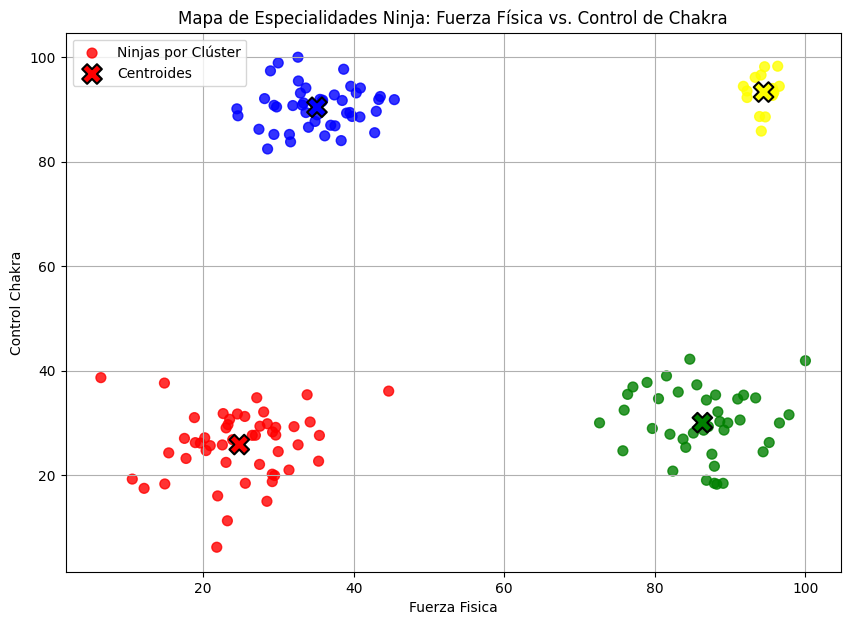

In [36]:
import matplotlib.pyplot as plt

colores_dict = {0: 'red', 1: 'blue', 2: 'green', 3: 'yellow'}

# Creamos una lista de colores basada en las predicciones del modelo K-Means
colores_puntos = [colores_dict[i] for i in df['clan_comportamiento']]
colores_centroides = [colores_dict[i] for i in range(len(centroides))]

plt.figure(figsize=(10, 7))
plt.scatter(df['fuerza_fisica'], df['control_chakra'], c=colores_puntos, s=50, alpha=0.8, label='Ninjas por Clúster')

# Dibujamos los centroides con un marcador distintivo
plt.scatter(centroides[:, 0], centroides[:, 1], marker='X', s=200, c=colores_centroides, edgecolor='black', linewidth=1.5, label='Centroides')

plt.xlabel('Fuerza Fisica')
plt.ylabel('Control Chakra')
plt.title('Mapa de Especialidades Ninja: Fuerza Física vs. Control de Chakra')
plt.legend()
plt.grid(True)
plt.show()

---
# 5. Análisis de Perfiles.

###Examina las coordenadas de los centroides y pon nombre a cada unidad especializada (ej: “Médicos”, “Fuerza de Choque”, “Exploradores”).

**Grupo Rojo:** Estos son los que tiene poco Chakra y poca fuerza, son los que hacen misiones faciles en la aldea.

**Grupo Verde:** Tienen mucha fuerza y pcoo Chakra, estos se encagran de pelear en la guardia contra enemigos sin chakra.

**Grupo Amarillo:** Estos son los soldados más duertes y on mayor chakra estos son los que van delante en la guerra siendo los más fuertes.

**Grupo Azul:** Poca fuerza y mucho Chakra estos se encargan de curar a los soldados.